# Introduction

The objective of this project is to analyze, develop, and evaluate a machine learning model designed to support decision-making in a business environment. In a world where data is generated at an unprecedented rate and volume, the ability to transform information into actionable insights has become a critical factor for improving operational efficiency, reducing costs, and optimizing business processes.

Throughout the project, key data science techniques are applied, including data preparation, feature selection, categorical variable encoding, feature scaling, and the evaluation of supervised learning models. In addition, relevant performance metrics are used to assess predictive accuracy, while strategies such as class imbalance handling, cross-validation, and hyperparameter tuning are implemented to improve model robustness and generalization.

The primary goal is to demonstrate how machine learning tools can generate real business value by identifying patterns, anticipating outcomes, and supporting strategic decisions through rigorous quantitative analysis. This document presents each stage of the process, including its theoretical foundations, methodology, and the conclusions derived from the results obtained.

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils import shuffle
from sklearn.metrics import mean_absolute_error

In [2]:
pd.set_option('display.max_columns', None)
sep = '\n ------------------------------------------------------------------------------- \n'

In [3]:
train = pd.read_csv('/datasets/gold_recovery_train.csv', sep=',')
test = pd.read_csv('/datasets/gold_recovery_test.csv', sep=',')
full = pd.read_csv('/datasets/gold_recovery_full.csv', sep=',')

In [4]:
# Create a function to examine dataframes
def examine(data):
    data.info()
    print(sep)
    print(data.head())
    print(sep)
    print(data.describe(include='all'))
    print(sep)
    print(data.duplicated().sum())
    print(sep)
    print(data['date'].duplicated().sum())

examine(train)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


In [5]:
examine(test)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_clea

In [6]:
examine(full)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                               22445 non-null  float64


Upon examining the data, it becomes evident that the test dataset is missing several columns, including those required to calculate both the **rougher recovery** and the **final recovery**. Consequently, these target variables must be estimated using a regression model.

Additionally, it was observed that many of the features contain missing values or values equal to zero. These entries likely result from measurement errors, data collection issues, or inconsistencies in the process used to record the operational parameters. Addressing these data quality issues will be an important step in the data preparation stage to ensure reliable model performance.

### 1.2 Recovery Calculation

In [7]:
# Create a new dataset with the required columns for the calculation of the rougher recovery and delete null values
recovery_data = full[['rougher.output.concentrate_au', 'rougher.input.feed_au', 'rougher.output.tail_au', 'rougher.output.recovery']].dropna()
# assign every column to a variable
real_recovery = recovery_data['rougher.output.recovery']
c = recovery_data['rougher.output.concentrate_au']
f = recovery_data['rougher.input.feed_au']
t = recovery_data['rougher.output.tail_au']
# calculate the recovery using the variables and the equation provided
rec_calc = ((c * (f - t))/(f * (c - t))) * 100
# Calculate the MAE between the real recovery and the calculation made done with the formula
mae = mean_absolute_error(real_recovery, rec_calc)
# show the results
print(real_recovery.head(10), sep, rec_calc.head(10), sep, mae, sep='')

0    87.107763
1    86.843261
2    86.842308
3    87.226430
4    86.688794
5    88.156912
6    88.168065
7    87.668336
8    87.035862
9    87.650868
Name: rougher.output.recovery, dtype: float64
 ------------------------------------------------------------------------------- 
0    87.107763
1    86.843261
2    86.842308
3    87.226430
4    86.688794
5    88.156912
6    88.168065
7    87.668336
8    87.035862
9    87.650868
dtype: float64
 ------------------------------------------------------------------------------- 
9.849655974293876e-15


After calculating the **rougher recovery** for the training dataset using the provided formula and comparing the results with the actual recovery values measured during the production process, an extremely low **Mean Absolute Error (MAE)** was obtained. This indicates that the calculated values closely match the real recovery measurements, demonstrating a high degree of accuracy.

Therefore, the recovery values derived from the formula can be considered reliable and suitable for use in the development and evaluation of the regression model.

### 1.3 Analysis of Features Missing from the Test Dataset

In [8]:
# Create a set with the difference between the columns on both sets
missing_feats = set(train.columns) - set(test.columns)
missing_feats = train[missing_feats].dtypes
print(missing_feats.sort_index())

final.output.concentrate_ag                           float64
final.output.concentrate_au                           float64
final.output.concentrate_pb                           float64
final.output.concentrate_sol                          float64
final.output.recovery                                 float64
final.output.tail_ag                                  float64
final.output.tail_au                                  float64
final.output.tail_pb                                  float64
final.output.tail_sol                                 float64
primary_cleaner.output.concentrate_ag                 float64
primary_cleaner.output.concentrate_au                 float64
primary_cleaner.output.concentrate_pb                 float64
primary_cleaner.output.concentrate_sol                float64
primary_cleaner.output.tail_ag                        float64
primary_cleaner.output.tail_au                        float64
primary_cleaner.output.tail_pb                        float64
primary_

Upon analyzing the features missing from the test dataset, the previous observation is confirmed: the variables required to calculate both the **rougher recovery** and **final recovery** are not available. In fact, none of the output variables associated with the different stages of the production process are present in the test set.

The absence of these target-related variables makes it necessary to rely on regression models to estimate the recovery indicators. Consequently, the predictive models developed in this project will focus on learning the relationship between the available process parameters and the corresponding recovery values observed in the training data.

### 1.4 Data Preprocessing 

In [9]:
# create a list with the columns available in the test set
test_feats = list(test.columns)
# create a new training set filtering the columns in common with the test set
new_train = train[test_feats + ['rougher.output.recovery', 'final.output.recovery']].copy()
# check the change
missing = set(new_train.columns) - set(test.columns)
print(missing)
print(sep)
examine(new_train)

{'final.output.recovery', 'rougher.output.recovery'}

 ------------------------------------------------------------------------------- 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 55 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        16860 non-null  object 
 1   primary_cleaner.input.sulfate               15553 non-null  float64
 2   primary_cleaner.input.depressant            15598 non-null  float64
 3   primary_cleaner.input.feed_size             16860 non-null  float64
 4   primary_cleaner.input.xanthate              15875 non-null  float64
 5   primary_cleaner.state.floatbank8_a_air      16820 non-null  float64
 6   primary_cleaner.state.floatbank8_a_level    16827 non-null  float64
 7   primary_cleaner.state.floatbank8_b_air      16820 non-null  float64
 8   primary_cleaner.sta

A new DataFrame was created from the training dataset, retaining only the columns that are also present in the test dataset, as these represent the features available for predicting the recovery values. This step is essential because the model cannot be trained on variables that will not be available when making real-world predictions.

Ensuring consistency between the training and test datasets helps prevent issues during inference and guarantees that the model learns exclusively from information that will be accessible at prediction time. This approach improves the reliability and practical applicability of the resulting regression models.

# 2. data analysis

# 2.1 material concentration

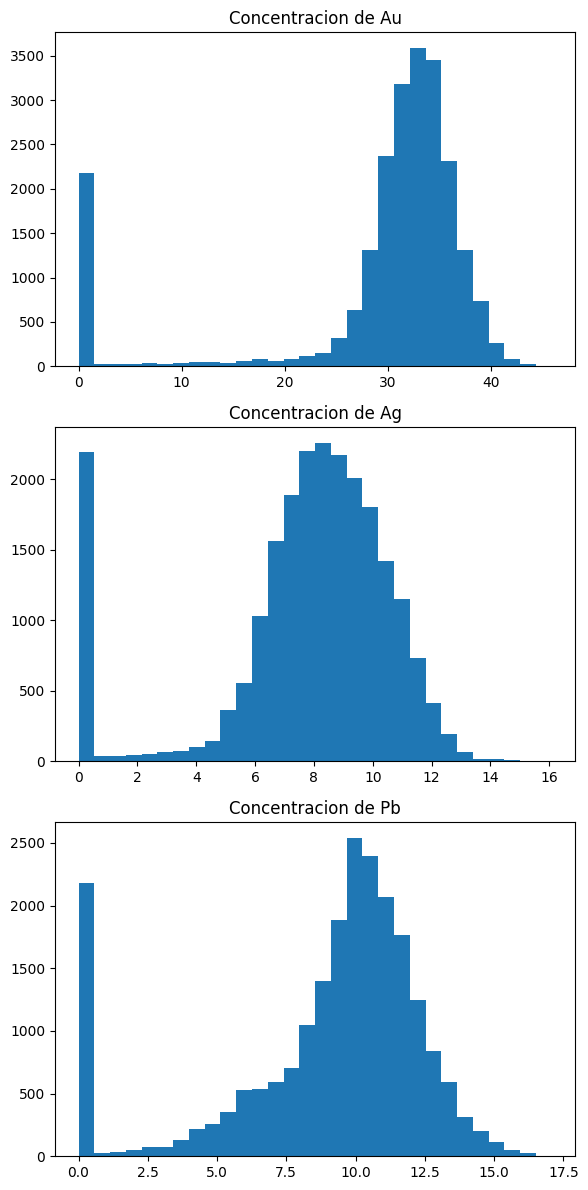

In [10]:
'''create a function that plots histograms to show the distribution of different values.'''

def plot_concentrates(columns, titles):
    fig, ax = plt.subplots(len(columns), 1, figsize=(6, 12))
    
    for i, s in enumerate(columns):
        ax[i].hist(s, bins=30)
        ax[i].set_title(titles[i])
    
    plt.tight_layout()
    plt.show()

concentrates = [full['primary_cleaner.output.concentrate_au'],
                full['primary_cleaner.output.concentrate_ag'], 
                full['primary_cleaner.output.concentrate_pb']]

titles = ['Au Concentration', 'Ag concentration', 'Pb concentration']

plot_concentrates(concentrates, titles)

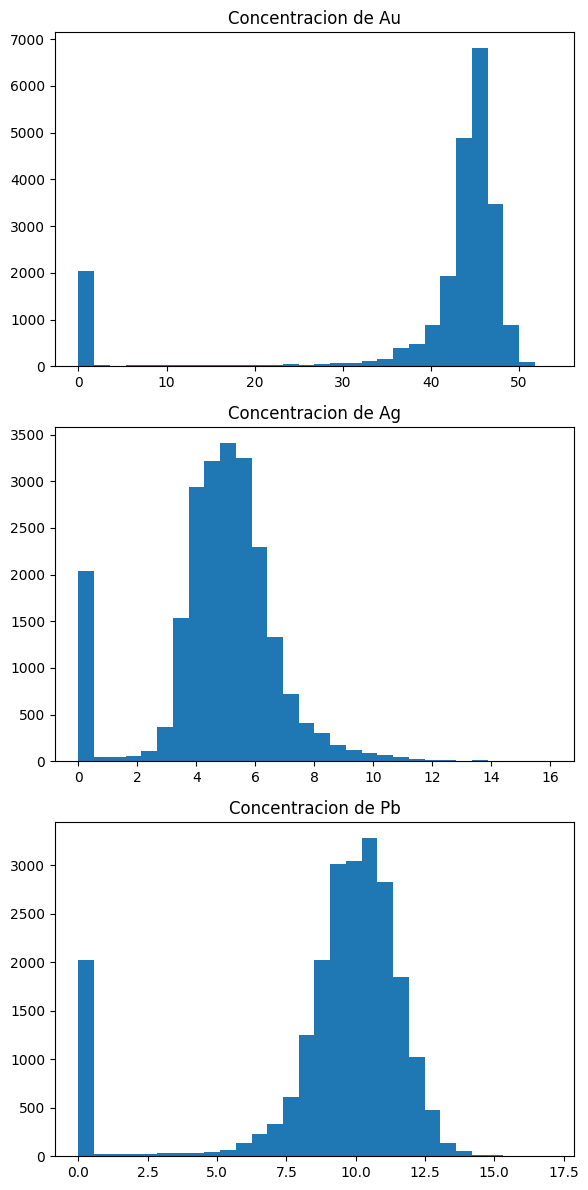

In [11]:
concentrates = [full['final.output.concentrate_au'],
                full['final.output.concentrate_ag'], 
                full['final.output.concentrate_pb']]

titles = ['Au concentration', 'Ag Concentration', 'Pb Concentration']

plot_concentrates(concentrates, titles)

### Conclusion

First, it can be observed that the concentration of gold increases progressively throughout each stage of the process. This behavior is consistent with the objective of the production system, which is to maximize the proportion of gold in the final product. In contrast, the concentration of silver decreases as the process advances, while the concentration of lead remains relatively stable, although with a narrower and less dispersed distribution. This may indicate that additional purification stages could be required to further reduce the presence of lead in the processed material.

Additionally, all distributions become progressively narrower, suggesting a reduction in data variability as the material moves through the production process. This pattern indicates that the process not only increases gold concentration but also produces a more homogeneous output over time.

Finally, several concentration values equal to zero were identified. Since such values are not physically meaningful in this context, they are likely the result of measurement errors, data recording issues, or other inconsistencies in the data collection process. These observations highlight the importance of data preprocessing and quality control before developing predictive models.

# 2.2 distributuion comparison

In [1]:
# Analyze the distribution of feed particle sizes in the flotation and primary cleaning stages of the training dataset
feed_sizes = [new_train['rougher.input.feed_size'],
              new_train['primary_cleaner.input.feed_size']]

titles = ['Rougher feed particle size',
          'primary cleaner feed particle size']

plot_concentrates(feed_sizes, titles)

NameError: name 'new_train' is not defined

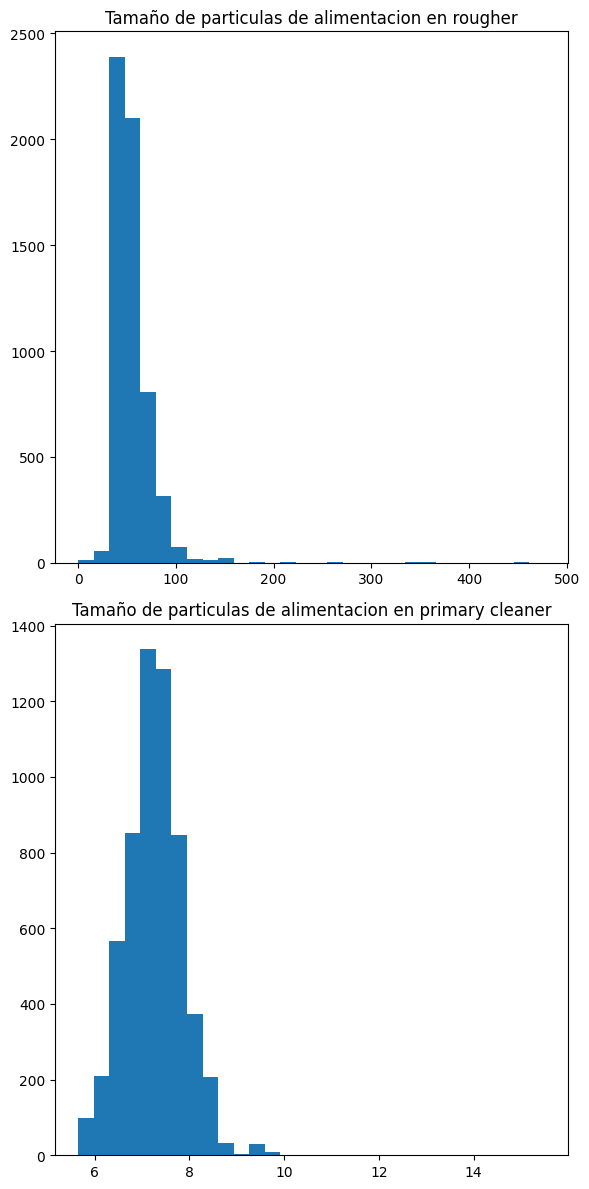

In [13]:
# Analyze the distribution of feed particle sizes in the flotation and primary cleaning stages of the test dataset

feed_sizes = [test['rougher.input.feed_size'],
              test['primary_cleaner.input.feed_size']]

titles = ['Rougher feed particle size',
          'Primary cleaner feed particle size']

plot_concentrates(feed_sizes, titles)

### Conclusion

With the exception of a few outliers, the particle size distributions are highly similar between the training and test datasets. This consistency suggests that there are no significant differences in the way these variables were measured or in their underlying behavior across the two datasets.

As a result, these features can be considered reliable predictors for estimating recovery values in the test dataset using a model trained on the training data. The similarity between the distributions also indicates that the training and test sets are representative of the same underlying process, which supports the validity and generalizability of the predictive models developed in this project.

# 2.3 Total concentrations

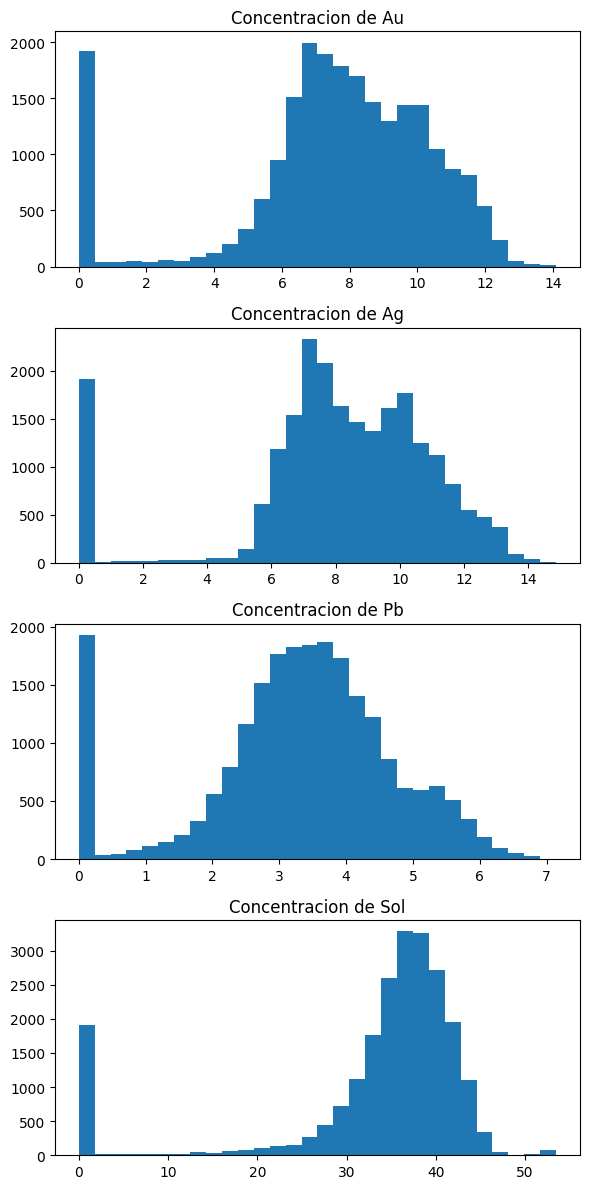

In [14]:
# Concentration of elements in the raw material

concentrates = [full['rougher.input.feed_au'],
              full['rougher.input.feed_ag'], 
              full['rougher.input.feed_pb'],
              full['rougher.input.feed_sol']]

titles = ['Au concentration',
          'Ag concentration',
          'Pb concentration',
          'Sol concentration']

plot_concentrates(concentrates, titles)

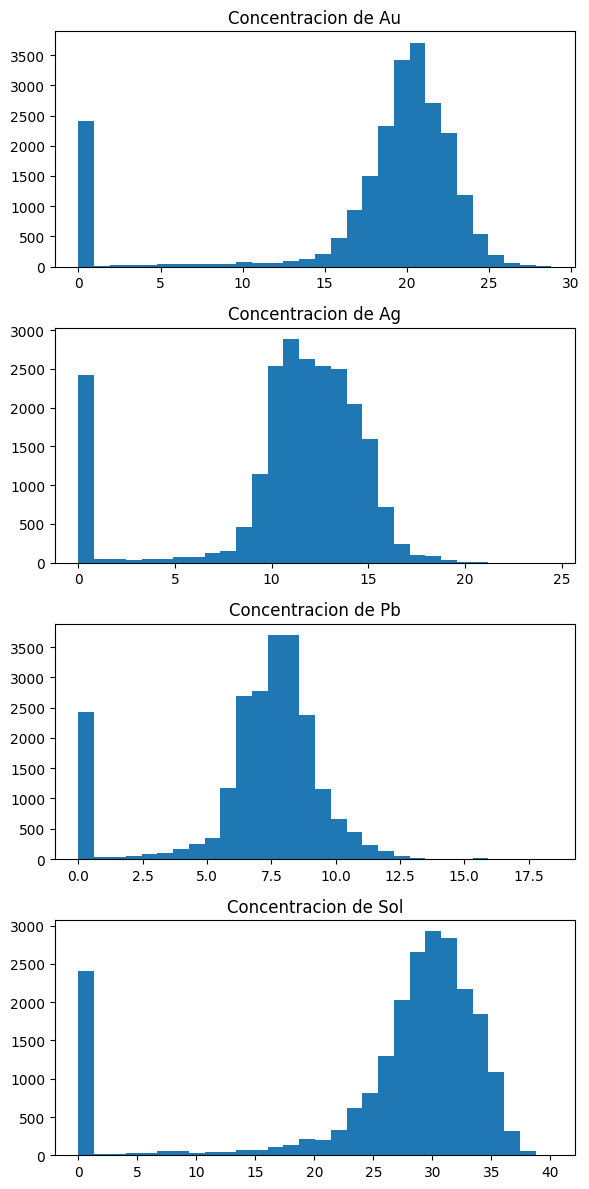

In [15]:
# Concentration of elements in the rougher concentrate

concentrates = [full['rougher.output.concentrate_au'],
                full['rougher.output.concentrate_ag'], 
                full['rougher.output.concentrate_pb'],
                full['rougher.output.concentrate_sol']]

titles = ['Au concentration',
          'Ag concentration',
          'Pb concentration',
          'Sol concentration']

plot_concentrates(concentrates, titles)

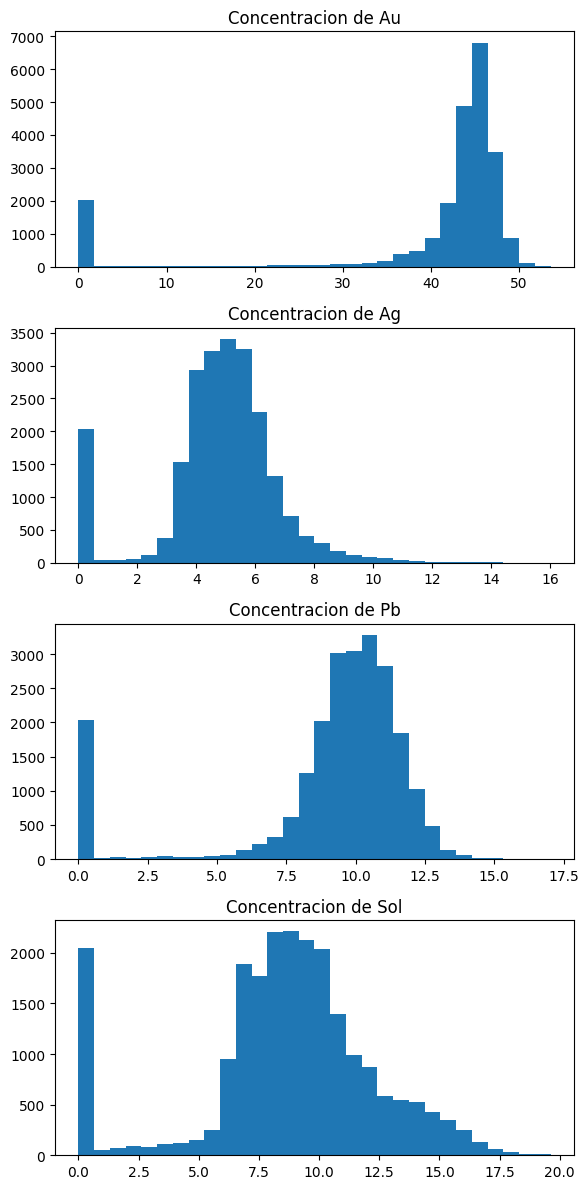

In [16]:
# Concentration of elements in the final concentrate

concentrates = [full['final.output.concentrate_au'],
                full['final.output.concentrate_ag'], 
                full['final.output.concentrate_pb'],
                full['final.output.concentrate_sol']]

titles = ['Au concentration',
          'Ag concentration',
          'Pb concentration',
          'Sol concentration']

plot_concentrates(concentrates, titles)

Upon analyzing the distributions of the different elements throughout each stage of the production process, peaks at values equal to zero are once again observed. These values are not physically meaningful, as a sudden zero concentration in a batch of ore containing significant amounts of material is highly unlikely.

Therefore, it is reasonable to conclude that these zero values result from measurement errors, data recording issues, or other inconsistencies in the data collection process. As a result, they should be appropriately addressed during the data cleaning and preprocessing stage to ensure the quality and reliability of the dataset used for model development.

In [17]:
# Investigate observations with zero element concentrations throughout the different stages of the production process

# concentration of elements in the feeding stage
feed = ['rougher.input.feed_au', 'rougher.input.feed_ag', 'rougher.input.feed_pb',
        'rougher.input.feed_sol'] 

# concentration of elements in the floatation stage
rougher_output = ['rougher.output.concentrate_au', 'rougher.output.concentrate_ag',
        'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol']

# final concentration of elements
final_output = ['final.output.concentrate_au', 'final.output.concentrate_ag', 'final.output.concentrate_pb',
        'final.output.concentrate_sol']

# Recoveries
recoveries = ['rougher.output.recovery', 'final.output.recovery']

# filter out zero values
full_zero = full[full[feed + rougher_output + final_output + recoveries].eq(0).any(axis=1)]\
    [feed + rougher_output + final_output + recoveries]
full_zero.info()
print(sep)
print(full_zero.head(), sep, sep='')
print(full_zero.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2244 entries, 45 to 18220
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   rougher.input.feed_au           2235 non-null   float64
 1   rougher.input.feed_ag           2236 non-null   float64
 2   rougher.input.feed_pb           2227 non-null   float64
 3   rougher.input.feed_sol          2156 non-null   float64
 4   rougher.output.concentrate_au   2236 non-null   float64
 5   rougher.output.concentrate_ag   2236 non-null   float64
 6   rougher.output.concentrate_pb   2236 non-null   float64
 7   rougher.output.concentrate_sol  2199 non-null   float64
 8   final.output.concentrate_au     2237 non-null   float64
 9   final.output.concentrate_ag     2237 non-null   float64
 10  final.output.concentrate_pb     2237 non-null   float64
 11  final.output.concentrate_sol    2232 non-null   float64
 12  rougher.output.recovery         

In [18]:
# delete recovery values equal to zero and NaN

print((new_train[recoveries] == 0).sum())
print(new_train[recoveries].isna().sum())

new_train.loc[:, recoveries] = new_train[recoveries].replace(0, np.nan)

print((new_train[recoveries] == 0).sum())
print(new_train[recoveries].isna().sum())

new_train = new_train.dropna(subset = recoveries).copy()

print((new_train[recoveries] == 0).sum())
print(new_train[recoveries].isna().sum())

examine(new_train)

rougher.output.recovery    320
final.output.recovery       89
dtype: int64
rougher.output.recovery    2573
final.output.recovery      1521
dtype: int64
rougher.output.recovery    0
final.output.recovery      0
dtype: int64
rougher.output.recovery    2893
final.output.recovery      1610
dtype: int64
rougher.output.recovery    0
final.output.recovery      0
dtype: int64
rougher.output.recovery    0
final.output.recovery      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 13795 entries, 0 to 16859
Data columns (total 55 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        13795 non-null  object 
 1   primary_cleaner.input.sulfate               13776 non-null  float64
 2   primary_cleaner.input.depressant            13769 non-null  float64
 3   primary_cleaner.input.feed_size             13795 non-null  float64
 4   primar

Upon analyzing the zero values present across the different features, a considerable number of both zero and missing values were identified. It is particularly noteworthy that these values also appear in the recovery variables, which is not physically plausible. A batch of ore containing significant amounts of material cannot realistically exhibit zero concentrations at intermediate stages of the production process.

Therefore, it is reasonable to assume that these values are the result of measurement errors, data recording issues, or other inconsistencies in the data collection process. As such, they must be properly addressed during the data preparation stage.

Since these values occur in the target variables that the model is intended to predict, the decision was made to remove the affected observations rather than impute them with artificial values. Filling these records with unrealistic estimates could introduce noise and bias into the dataset, negatively impacting the model's ability to learn meaningful patterns from the production process. Consequently, removing these observations was considered the most appropriate approach for preserving the quality and integrity of the training data.

In [19]:
# Define the feature set and target variables for each training dataset

features_train = new_train.drop(columns=['final.output.recovery',
                                          'rougher.output.recovery']).copy()
target_rough_recovery = new_train['rougher.output.recovery'].copy()
target_final_recovery = new_train['final.output.recovery'].copy()
print(features_train.shape, sep,
      target_rough_recovery.shape, sep,
      target_final_recovery.shape, sep='')

(13795, 53)
 ------------------------------------------------------------------------------- 
(13795,)
 ------------------------------------------------------------------------------- 
(13795,)


In [20]:
# Fill missing values using forward-fill and backward-fill imputation

def impute(data):
    data = data.copy()
    data = data.replace(0, np.nan)
    data['date'] = pd.to_datetime(data['date'])
    data = data.sort_values('date')
    data = data.ffill().bfill()
    return data

features_train = impute(features_train)
print(features_train.isna().sum(), sep)
features_train.info()

date                                          0
primary_cleaner.input.sulfate                 0
primary_cleaner.input.depressant              0
primary_cleaner.input.feed_size               0
primary_cleaner.input.xanthate                0
primary_cleaner.state.floatbank8_a_air        0
primary_cleaner.state.floatbank8_a_level      0
primary_cleaner.state.floatbank8_b_air        0
primary_cleaner.state.floatbank8_b_level      0
primary_cleaner.state.floatbank8_c_air        0
primary_cleaner.state.floatbank8_c_level      0
primary_cleaner.state.floatbank8_d_air        0
primary_cleaner.state.floatbank8_d_level      0
rougher.input.feed_ag                         0
rougher.input.feed_pb                         0
rougher.input.feed_rate                       0
rougher.input.feed_size                       0
rougher.input.feed_sol                        0
rougher.input.feed_au                         0
rougher.input.floatbank10_sulfate             0
rougher.input.floatbank10_xanthate      

In [21]:
test = impute(test)
print(test.isna().sum(), sep)
test.info()

date                                          0
primary_cleaner.input.sulfate                 0
primary_cleaner.input.depressant              0
primary_cleaner.input.feed_size               0
primary_cleaner.input.xanthate                0
primary_cleaner.state.floatbank8_a_air        0
primary_cleaner.state.floatbank8_a_level      0
primary_cleaner.state.floatbank8_b_air        0
primary_cleaner.state.floatbank8_b_level      0
primary_cleaner.state.floatbank8_c_air        0
primary_cleaner.state.floatbank8_c_level      0
primary_cleaner.state.floatbank8_d_air        0
primary_cleaner.state.floatbank8_d_level      0
rougher.input.feed_ag                         0
rougher.input.feed_pb                         0
rougher.input.feed_rate                       0
rougher.input.feed_size                       0
rougher.input.feed_sol                        0
rougher.input.feed_au                         0
rougher.input.floatbank10_sulfate             0
rougher.input.floatbank10_xanthate      

Unlike the recovery variables, the zero and missing values found in the feature set were imputed using the immediately preceding value. This approach makes it possible to retain as much information as possible without removing a substantial number of observations from the dataset.

Furthermore, this strategy is considered appropriate because these process variables tend to exhibit relatively stable behavior over time. Therefore, assuming continuity between consecutive measurements is reasonable within the context of the production process. By applying this imputation method, the dataset remains largely intact while preserving the underlying patterns necessary for effective model training.

# 3. Machine learning models

### 3.1 sMAPE formula

In [22]:
# define a function to calculate the metric sMAPE

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2

    #avoid division by 0
    mask = denominator == 0
    denominator[mask] = 1 #variable temporal para evitar dividir por 0
    result = numerator / denominator
    result[mask] = 0 #define el smape como 0 cuando ambos valores son 0

    return np.mean(result) * 100

In [23]:
# define a function to calculate the final sMape

def final_smape(rougher, final):
    final_smape = (0.25 * rougher) + (0.75 * final)
    return final_smape

In [24]:
# test the function
true = np.array([1, 0, 3])
pred = pd.Series([2, 0, 3])
print(smape(true, pred))

22.22222222222222


### 3.1 entrenamiento de modelos

In [25]:
# prepare all the dataframes with need for training and testing models

features_train.info()
print(sep)
print(target_rough_recovery.head(), len(target_rough_recovery))
print(sep)
print(target_final_recovery.head(), len(target_final_recovery))
print(sep)
test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13795 entries, 0 to 16859
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        13795 non-null  datetime64[ns]
 1   primary_cleaner.input.sulfate               13795 non-null  float64       
 2   primary_cleaner.input.depressant            13795 non-null  float64       
 3   primary_cleaner.input.feed_size             13795 non-null  float64       
 4   primary_cleaner.input.xanthate              13795 non-null  float64       
 5   primary_cleaner.state.floatbank8_a_air      13795 non-null  float64       
 6   primary_cleaner.state.floatbank8_a_level    13795 non-null  float64       
 7   primary_cleaner.state.floatbank8_b_air      13795 non-null  float64       
 8   primary_cleaner.state.floatbank8_b_level    13795 non-null  float64       
 9   primar

In [26]:
# Split the train set into train and validation

final_features_train, features_valid, rough_recovery_train, rough_recovery_valid, final_recovery_train, final_recovery_valid = train_test_split(features_train, target_rough_recovery, target_final_recovery, test_size=0.25, random_state=1012)
print(
    'final_features_train =', final_features_train.shape, '\n',
    'features_valid =', features_valid.shape, '\n',
    'rough_recovery_train =', rough_recovery_train.shape, '\n',
    'rough_recovery_valid =', rough_recovery_valid.shape, '\n',
    'final_recovery_train =', final_recovery_train.shape, '\n',
    'final_recovery_valid =', final_recovery_valid.shape
    , sep=''
)
print(features_train.shape)

final_features_train =(10346, 53)
features_valid =(3449, 53)
rough_recovery_train =(10346,)
rough_recovery_valid =(3449,)
final_recovery_train =(10346,)
final_recovery_valid =(3449,)
(13795, 53)


In [27]:
# Merge the test dataset with the rougher and final recovery values from the source dataset
# in order to match each test observation with its corresponding targets and calculate
# the sMAPE metric after model evaluation

#filter the date and recoveries columns from the full set
df_to_merge = full[['date'] + recoveries].copy()
# convert date column to datetime
df_to_merge['date'] = pd.to_datetime(df_to_merge['date'].copy())
# merge the test dataset with the recoveries using date as the common column
new_test = test.merge(df_to_merge, how='left', on='date') 
# convert zeros in NaN in the recoveries columns and delete these values like we did previously
new_test.loc[:, recoveries] = new_test[recoveries].replace(0, np.nan)
new_test = new_test.dropna(subset = recoveries).copy()
print((new_train[recoveries] == 0).sum())
print(new_train[recoveries].isna().sum())

rougher.output.recovery    0
final.output.recovery      0
dtype: int64
rougher.output.recovery    0
final.output.recovery      0
dtype: int64


In [28]:
# define the features and targets of the test set

features_test = new_test.drop(columns=recoveries).copy()
rough_recovery_test = new_test['rougher.output.recovery'].copy()
final_recovery_test = new_test['final.output.recovery'].copy()
print(
    features_test.shape, '\n',
    rough_recovery_test.shape, '\n',
    final_recovery_test.shape, '\n',
    sep=''
)

(5154, 53)
(5154,)
(5154,)



In [29]:
# Impute missing values in the test dataset to ensure that all features are complete

impute(features_test)
print((features_test == 0).sum())
print(features_test.isna().sum())

date                                          0
primary_cleaner.input.sulfate                 0
primary_cleaner.input.depressant              0
primary_cleaner.input.feed_size               0
primary_cleaner.input.xanthate                0
primary_cleaner.state.floatbank8_a_air        0
primary_cleaner.state.floatbank8_a_level      0
primary_cleaner.state.floatbank8_b_air        0
primary_cleaner.state.floatbank8_b_level      0
primary_cleaner.state.floatbank8_c_air        0
primary_cleaner.state.floatbank8_c_level      0
primary_cleaner.state.floatbank8_d_air        0
primary_cleaner.state.floatbank8_d_level      0
rougher.input.feed_ag                         0
rougher.input.feed_pb                         0
rougher.input.feed_rate                       0
rougher.input.feed_size                       0
rougher.input.feed_sol                        0
rougher.input.feed_au                         0
rougher.input.floatbank10_sulfate             0
rougher.input.floatbank10_xanthate      

In [30]:
# delete the date column since it doesn't provide relevant information for the prediction of the recoveries

features_train = features_train.drop(columns=['date'])
final_features_train = final_features_train.drop(columns=['date'])
features_valid = features_valid.drop(columns=['date'])
features_test = features_test.drop(columns=['date'])

print(
    features_train.shape, features_train.isna().sum(), '\n',
    final_features_train.shape, final_features_train.isna().sum(), '\n',
    features_valid.shape, features_valid.isna().sum(), '\n',
    features_test.shape, features_test.isna().sum()
)

(13795, 52) primary_cleaner.input.sulfate                 0
primary_cleaner.input.depressant              0
primary_cleaner.input.feed_size               0
primary_cleaner.input.xanthate                0
primary_cleaner.state.floatbank8_a_air        0
primary_cleaner.state.floatbank8_a_level      0
primary_cleaner.state.floatbank8_b_air        0
primary_cleaner.state.floatbank8_b_level      0
primary_cleaner.state.floatbank8_c_air        0
primary_cleaner.state.floatbank8_c_level      0
primary_cleaner.state.floatbank8_d_air        0
primary_cleaner.state.floatbank8_d_level      0
rougher.input.feed_ag                         0
rougher.input.feed_pb                         0
rougher.input.feed_rate                       0
rougher.input.feed_size                       0
rougher.input.feed_sol                        0
rougher.input.feed_au                         0
rougher.input.floatbank10_sulfate             0
rougher.input.floatbank10_xanthate            0
rougher.input.floatbank11_su

In [31]:
# scale the features in all teh sets

scaler = StandardScaler()
scaler.fit(features_train)
features_train = pd.DataFrame(
    scaler.transform(features_train),
    columns=features_train.columns,
    index=features_train.index
)
final_features_train = pd.DataFrame(
    scaler.transform(final_features_train),
    columns=final_features_train.columns,
    index=final_features_train.index
)
features_valid = pd.DataFrame(
    scaler.transform(features_valid),
    columns=features_valid.columns,
    index=features_valid.index
)
features_test = pd.DataFrame(
    scaler.transform(features_test),
    columns=features_test.columns,
    index=features_test.index
)

# Model training

#### sets for initial training and validation
- final_features_train 
- features_valid 
- rough_recovery_train 
- rough_recovery_valid 
- final_recovery_train 
- final_recovery_valid

#### sets for final training and test
- features_train
- features_test
- target_rough_recovery
- rough_recovery_test
- target_final_recovery 
- final_recovery_test

In [32]:
# check the dataframes' sizes to ensure consistency

print(features_train.shape, type(features_train))
print(final_features_train.shape, type(final_features_train))
print(features_valid.shape, type(features_valid))
print(features_test.shape, type(features_test))

(13795, 52) <class 'pandas.core.frame.DataFrame'>
(10346, 52) <class 'pandas.core.frame.DataFrame'>
(3449, 52) <class 'pandas.core.frame.DataFrame'>
(5154, 52) <class 'pandas.core.frame.DataFrame'>


In [33]:
print(rough_recovery_valid.shape, type(rough_recovery_valid))

(3449,) <class 'pandas.core.series.Series'>


In [34]:
# train a regression tree

def tree(
    features_train,
    features_valid,
    rough_recovery_train,
    rough_recovery_valid,
    final_recovery_train,
    final_recovery_valid
):
    
    best_smape_rough = float('inf')
    best_depth_rough = 0
    for depth in range(1, 10): 
        model = DecisionTreeRegressor(max_depth=depth, random_state=1012) 
        model.fit(features_train, rough_recovery_train)
        predictions_rough = model.predict(features_valid) 
        result = smape(rough_recovery_valid, predictions_rough) 
        if result < best_smape_rough:
            best_smape_rough = result
            best_depth_rough = depth
    
    print(f"sMAPE of the best model for the validation set (max_depth = {best_depth_rough}): {best_smape_rough}")
    
    best_smape_final = float('inf')
    best_depth_final = 0
    for depth in range(1, 10): # selecciona el rango del hiperparámetro, el límite superior no se incluye
        model = DecisionTreeRegressor(max_depth=depth, random_state=1012) # entrena el modelo en el conjunto de entrenamiento
        model.fit(features_train, final_recovery_train) # entrena el modelo en el conjunto de entrenamiento
        predictions_final = model.predict(features_valid) # obtén las predicciones del modelo en el conjunto de validación
        result = smape(final_recovery_valid, predictions_final) # calcula la RECM en el conjunto de validación
        if result < best_smape_final:
            best_smape_final = result
            best_depth_final = depth
    
    print(f"SMAPE of the best model for the alidation set (max_depth = {best_depth_final}): {best_smape_final}")
    
    overall_smape = (0.25 * best_smape_rough) + (0.75 * best_smape_final)
    print(f'final SMAPE of the model: {overall_smape}')
    return best_smape_rough, best_smape_final, overall_smape

smape_rough, smape_final, overall_smape = tree(
    final_features_train,
    features_valid,
    rough_recovery_train,
    rough_recovery_valid,
    final_recovery_train,
    final_recovery_valid
)    

SMAPE del mejor modelo en el conjunto de validación (max_depth = 9): 3.8302088607655915
SMAPE del mejor modelo en el conjunto de validación (max_depth = 9): 7.2093483340588485
SMAPE final del modelo: 6.364563465735534


In [35]:
#train a linear regression model 

def linear(
    features_train,
    features_valid,
    rough_recovery_train,
    rough_recovery_valid,
    final_recovery_train,
    final_recovery_valid
):
    
    model = LinearRegression() 
    model.fit(features_train, rough_recovery_train) 
    predictions_rough = model.predict(features_valid) 
    best_smape_rough = smape(rough_recovery_valid, predictions_rough) 
    
    print("SMAPE of the best model for the rough validation set", best_smape_rough)
     
    model = LinearRegression() 
    model.fit(features_train, final_recovery_train) 
    predictions_final = model.predict(features_valid) 
    best_smape_final = smape(final_recovery_valid, predictions_final) 
        
    print("SMAPE of the best model for the final validation set", best_smape_final)

    overall_smape = (0.25 * best_smape_rough) + (0.75 * best_smape_final)
    print(f'final SMAPE: {overall_smape}')
    return best_smape_rough, best_smape_final, overall_smape

smape_rough, smape_final, overall_smape = linear(
    final_features_train,
    features_valid,
    rough_recovery_train,
    rough_recovery_valid,
    final_recovery_train,
    final_recovery_valid
)

SMAPE del mejor modelo en el conjunto de validación rough: 4.613790927409884
SMAPE del mejor modelo en el conjunto de validación final: 7.968683860626537
SMAPE final del modelo: 7.129960627322373


In [ ]:
#train a random forest

def forest(
    features_train,
    features_valid,
    rough_recovery_train,
    rough_recovery_valid,
    final_recovery_train,
    final_recovery_valid
):
    best_smape_rough = float('inf') 
    best_est_rough = 0
    best_depth_rough = 0
    for est in [50, 100]:
        for depth in [5, 10, None]:
            model = RandomForestRegressor(random_state=1012, n_estimators=est, max_depth=depth, n_jobs=-1) 
            model.fit(features_train, rough_recovery_train) 
            predictions_rough = model.predict(features_valid) 
            result = smape(rough_recovery_valid, predictions_rough) 
            if result < best_smape_rough: 
                best_smape_rough = result
                best_est_rough = est
                best_depth_rough = depth
    
    print("SMAPE of the best model for the rough validation set:", best_smape_rough, "n_estimators:", best_est_rough, "best_depth:", best_depth_rough)

    best_smape_final = float('inf') 
    best_est_final = 0
    best_depth_final = 0
    for est in [50, 100]:
        for depth in [5, 10, None]:
            model = RandomForestRegressor(random_state=1012, n_estimators=est, max_depth=depth, n_jobs=-1) 
            model.fit(features_train, final_recovery_train) 
            predictions_final = model.predict(features_valid) 
            result = smape(final_recovery_valid, predictions_final)
            if result < best_smape_final: 
                best_smape_final = result
                best_est_final = est
                best_depth_final = depth
    
    print("SMAPE of the best model for the final validation set:", best_smape_final, "n_estimators:", best_est_final, "best_depth:", best_depth_final)

    overall_smape = (0.25 * best_smape_rough) + (0.75 * best_smape_final)
    print(f'final model SMAPE: {overall_smape}')
    return best_smape_rough, best_smape_final, overall_smape

smape_rough, smape_final, overall_smape = forest(
    final_features_train,
    features_valid,
    rough_recovery_train,
    rough_recovery_valid,
    final_recovery_train,
    final_recovery_valid
)

In [ ]:
#train the last model using the best result according to the validation

smape_rough, smape_final, overall_smape = forest(
    features_train, 
    features_test,
    target_rough_recovery,
    rough_recovery_test,
    target_final_recovery, 
    final_recovery_test
)

As observed in previous experiments, the **Random Forest Regressor** emerged as the most effective model for predicting the target variables. However, it is also the most computationally demanding approach, often requiring several minutes to generate results.

This characteristic implies a higher computational cost in terms of processing time and resources. Nevertheless, the additional complexity is justified by its superior predictive performance compared to the other models evaluated. As a result, the Random Forest Regressor represents a favorable trade-off between accuracy and computational efficiency for this particular problem.

# Final Conclusion

The analysis and modeling conducted throughout this project enabled the development of a predictive system capable of estimating both **rougher recovery** and **final recovery** using the features available in the test dataset. During the initial exploratory phase, several significant data quality issues were identified, including missing values, physically implausible zero concentrations, and the absence of key variables in the test set. These findings highlighted the need for a rigorous data cleaning and preparation process to ensure the consistency and reliability of the predictions.

Based on this analysis, observations containing invalid recovery values were removed, while missing and zero values within the feature set were imputed using the immediately preceding value. This approach leveraged the temporal continuity of the production process while preserving as much information as possible. Additionally, the distributions of particle sizes and other process variables were found to be consistent between the training and test datasets, validating the use of these features for model development.

Following data preparation, several regression approaches were evaluated. Among them, the **Random Forest Regressor** achieved the best performance for both target variables, despite requiring greater computational resources than alternative methods. The model's predictive accuracy indicates that it can generate reliable recovery estimates and provide valuable support for monitoring and optimizing the production process.

Overall, the results demonstrate that, through appropriate preprocessing and the selection of a robust machine learning model, it is possible to compensate for the absence of critical variables in the test dataset and produce accurate recovery predictions. This approach not only delivers immediate operational value but also establishes a foundation for future improvements in data quality, process automation, and the development of more advanced predictive systems.